In [1]:
%pip install -r utils/requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
!sudo apt update && sudo apt install -y libgl1 libglib2.0-0 libsm6 libxext6 libxrender-dev

Hit:1 https://packages.microsoft.com/repos/microsoft-ubuntu-noble-prod noble InRelease
Get:2 https://dl.yarnpkg.com/debian stable InRelease                           
Hit:3 http://archive.ubuntu.com/ubuntu noble InRelease                         
Hit:4 http://archive.ubuntu.com/ubuntu noble-updates InRelease                 
Hit:5 http://archive.ubuntu.com/ubuntu noble-backports InRelease               
Hit:6 https://repo.anaconda.com/pkgs/misc/debrepo/conda stable InRelease   
Err:2 https://dl.yarnpkg.com/debian stable InRelease                   
  The following signatures were invalid: EXPKEYSIG 23E7166788B63E1E Yarn Packaging <yarn@dan.cx>
Hit:7 http://security.ubuntu.com/ubuntu noble-security InRelease
Reading package lists... Done
W: GPG error: https://dl.yarnpkg.com/debian stable InRelease: The following signatures were invalid: EXPKEYSIG 23E7166788B63E1E Yarn Packaging <yarn@dan.cx>
E: The repository 'https://dl.yarnpkg.com/debian stable InRelease' is not signed.
N: Updating fr

In [17]:
# Cell 1: Install system dependencies FIRST
!sudo apt update && sudo apt install -y libgl1 libglib2.0-0 libsm6 libxext6 libxrender-dev

Get:1 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:2 https://packages.microsoft.com/repos/microsoft-ubuntu-noble-prod noble InRelease [3600 B]
Get:3 https://dl.yarnpkg.com/debian stable InRelease                       
0% [Connecting to repo.anaconda.com] [Connecting to archive.ubuntu.com (91.189.

Get:4 https://repo.anaconda.com/pkgs/misc/debrepo/conda stable InRelease [3961 B]
Get:5 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [1776 kB]
Get:6 http://archive.ubuntu.com/ubuntu noble InRelease [256 kB]
Get:7 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1194 kB]
Get:8 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [2919 kB]
Get:9 https://packages.microsoft.com/repos/microsoft-ubuntu-noble-prod noble/main amd64 Packages [85.7 kB]
Get:10 http://security.ubuntu.com/ubuntu noble-security/multiverse amd64 Packages [33.8 kB]
Get:11 https://packages.microsoft.com/repos/microsoft-ubuntu-noble-prod noble/main all Packages [650 B]
Err:3 https://dl.yarnpkg.com/debian stable InRelease                       
  The following signatures were invalid: EXPKEYSIG 23E7166788B63E1E Yarn Packaging <yarn@dan.cx>
Get:12 https://repo.anaconda.com/pkgs/misc/debrepo/conda stable/main amd64 Packages [4557 B]
Get:13 http://archiv

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from pathlib import Path

# Set up paths - Data is in utils/Data/Clean/
waldo_path = '/workspaces/wheres-wally/utils/Data/Clean/ClearedWaldos/'
heads_path = '/workspaces/wheres-wally/utils/Data/Clean/OnlyWaldoHeads/'

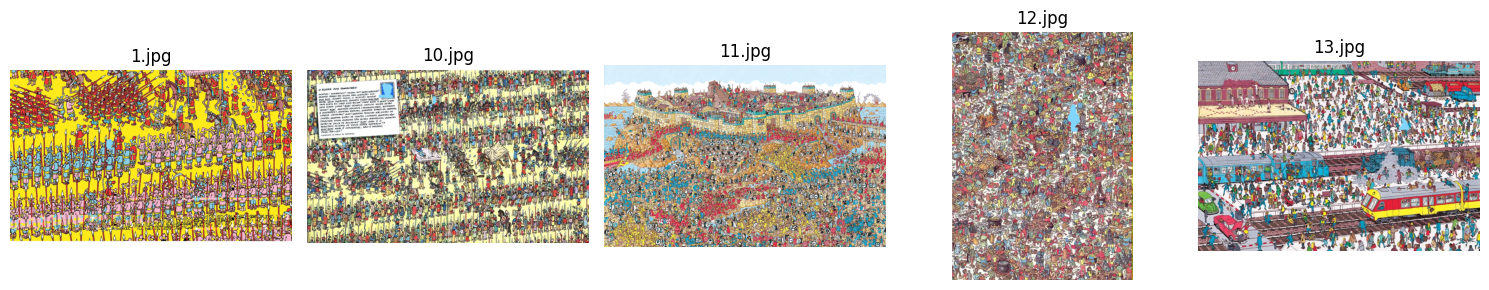

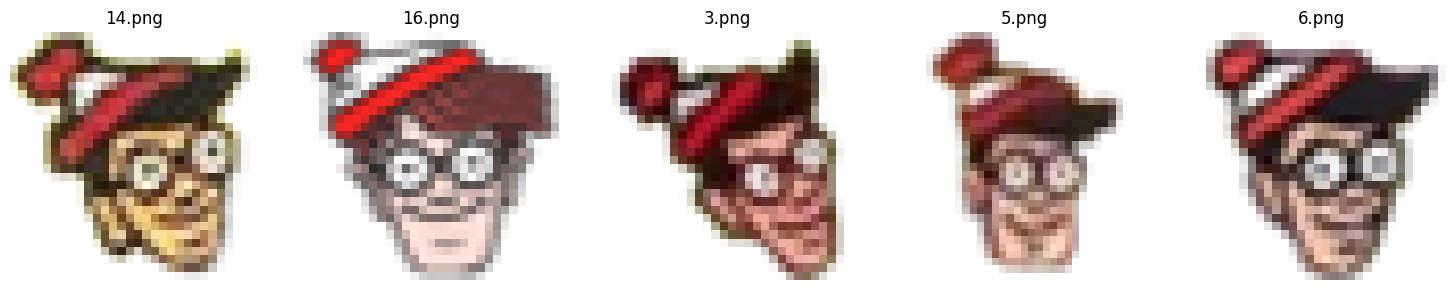

In [3]:
# Display examples of Only Wally
waldo_files = sorted([f for f in os.listdir(waldo_path) if f.endswith(('.jpg', '.png'))])
num_samples = min(5, len(waldo_files))

fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for idx, file in enumerate(waldo_files[:num_samples]):
    img = mpimg.imread(os.path.join(waldo_path, file))
    if num_samples == 1:
        axes.imshow(img)
        axes.set_title(file)
        axes.axis('off')
    else:
        axes[idx].imshow(img)
        axes[idx].set_title(file)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Display examples of Only Wally Heads
heads_files = sorted([f for f in os.listdir(heads_path) if f.endswith(('.jpg', '.png'))])
num_samples = min(5, len(heads_files))

fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for idx, file in enumerate(heads_files[:num_samples]):
    img = mpimg.imread(os.path.join(heads_path, file))
    if num_samples == 1:
        axes.imshow(img)
        axes.set_title(file)
        axes.axis('off')
    else:
        axes[idx].imshow(img)
        axes[idx].set_title(file)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [4]:
import os
import sys

os.chdir('/workspaces/wheres-wally/utils')
sys.path.insert(0, '/workspaces/wheres-wally/utils')

try:
    from DataAugmentation import generating_waldos
    generating_waldos(use_background=True)
except Exception as e:
    print(f"Error type: {type(e).__name__}")
    print(f"Error message: {e}")
    import traceback
    traceback.print_exc()

Data path: /workspaces/wheres-wally/utils/Data
Found 6 head images and 33 background images
Will generate 396 total images


Generated 396 training images


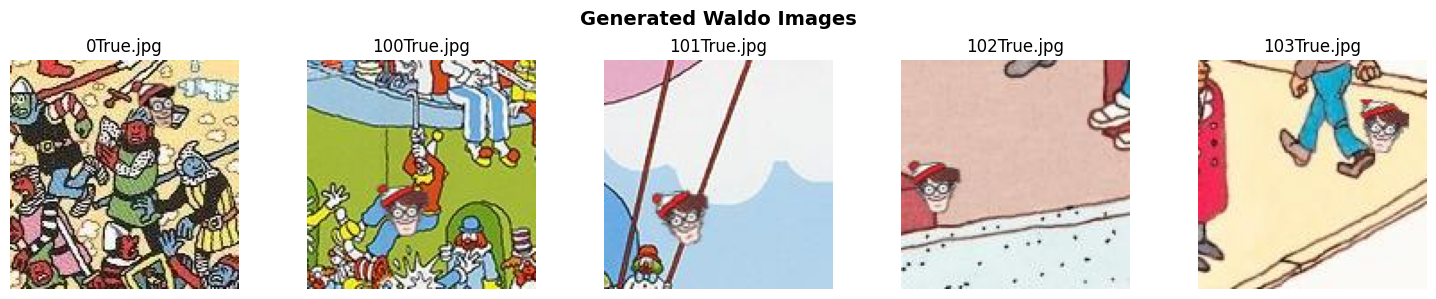

In [5]:
# List the generated Waldo images from the DataAugmentation output
waldo_generated_files = sorted([f for f in os.listdir('/workspaces/wheres-wally/utils/Data/Waldo') if f.endswith('.jpg')])[:5]

# Display 5 images from the generated Waldo dataset
fig, axes = plt.subplots(1, len(waldo_generated_files), figsize=(15, 3))
fig.suptitle('Generated Waldo Images', fontsize=14, fontweight='bold')

for idx, file in enumerate(waldo_generated_files):
    img = mpimg.imread(os.path.join('/workspaces/wheres-wally/utils/Data/Waldo', file))
    if len(waldo_generated_files) == 1:
        axes.imshow(img)
        axes.set_title(file)
        axes.axis('off')
    else:
        axes[idx].imshow(img)
        axes[idx].set_title(file)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [6]:
import os
import sys

# Add utils directory to Python path
utils_path = '/workspaces/wheres-wally/utils'
if utils_path not in sys.path:
    sys.path.insert(0, utils_path)

# Verify TrainModel.py exists
train_model_file = os.path.join(utils_path, 'TrainModel.py')
if os.path.exists(train_model_file):
    print(f"✓ Found TrainModel.py")
else:
    print(f"✗ TrainModel.py not found")
    print(f"Files in utils/: {[f for f in os.listdir(utils_path) if f.endswith('.py')]}")

✓ Found TrainModel.py


In [8]:
from TrainModel import train_waldo_model

# Train from scratch on your generated images
model, X_test, Y_test, score = train_waldo_model(
    data_path='Data',
    epochs=15,
    test_size=0.10,
    save_path='Models/localize_trained.h5'
)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'Models/localize7.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)